# 01 - Exploratory Data Analysis (EDA)
---
**Mục tiêu:** Khám phá và phân tích dữ liệu Credit Card Fraud Detection

**Nội dung:**
- Load dữ liệu
- Kiểm tra missing values, duplicates
- Phân tích phân bổ class (fraud vs non-fraud)
- Visualize các features quan trọng
- Statistical analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load data
print("Loading dataset...")
train = pd.read_csv('../data/raw/fraudTrain.csv')
print(f"Dataset loaded: {train.shape[0]} rows, {train.shape[1]} columns")
train.head(2)

Loading dataset...
Dataset loaded: 1296675 rows, 23 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [ ]:
# Load data
print("Loading test dataset...")
test = pd.read_csv('../data/raw/fraudTest.csv')
print(f"Dataset loaded: {test.shape[0]} rows, {test.shape[1]} columns")
test.head(2)

Loading test dataset...
Dataset loaded: 555719 rows, 23 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


## 1. Dataset Overview

In [ ]:
# Basic information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
train.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14

In [ ]:
numeric_cols = train.select_dtypes(include='number').columns
object_cols = train.select_dtypes(include=['object']).columns

print("Numeric columns:", len(numeric_cols))
print("Object columns:", len(object_cols))

print("\nList of numeric columns:")
print(numeric_cols.tolist())

print("\nList of object columns:")
print(object_cols.tolist())

Numeric columns: 11
Object columns: 12

List of numeric columns:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

List of object columns:
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [ ]:
# Statistical summary
train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
# Time range
print("Time range of transactions:")
print(f"Minimum time: {train['trans_date_trans_time'][0]}")
print(f"Maximum time: {train['trans_date_trans_time'].iloc[-1]}")

Time range of transactions:
Minimum time: 2019-01-01 00:00:18
Maximum time: 2020-06-21 12:13:37


In [ ]:
# Check for missing values
print("="*50)
print("MISSING VALUES")
print("="*50)
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

MISSING VALUES
No missing values found!


In [ ]:
# Check for duplicates
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage: {(duplicates/len(train))*100:.2f}%")

DUPLICATE ROWS
Number of duplicate rows: 0
Percentage: 0.00%


## Dataset Summary and Key Takeaways

- **Unnamed: 0**: Index/row identifier (can be dropped).
- **trans_date_trans_time**: Date and time of the transaction (important for time-based analysis).
- **cc_num**: Credit card number (can indicate fraud but is sensitive; not used directly).
- **merchant**: Merchant where the transaction occurred (useful for fraud tied to specific merchants).
- **category**: Category of goods/services purchased (may highlight fraud-prone categories).
- **amt**: Transaction amount (critical for identifying large, potentially fraudulent transactions).
- **first**: First name of the cardholder (usually not used in modeling).
- **last**: Last name of the cardholder (typically not used in fraud detection).
- **gender**: Gender of the cardholder (may or may not be useful depending on context).
- **street**: Street address of the cardholder (useful for location-based fraud detection).
- **city**: City of the cardholder (can help detect fraud based on location).
- **state**: State of the cardholder (location-based fraud detection).
- **zip**: ZIP code of the cardholder (helps identify location inconsistencies).
- **lat**: Latitude of the cardholder's location (useful for geolocation-based fraud detection).
- **long**: Longitude of the cardholder's location (works with lat for location-based fraud detection).
- **city_pop**: Population of the city (may provide context for detecting fraud).
- **job**: Occupation of the cardholder (generally low correlation with fraud).
- **dob**: Date of birth of the cardholder (can help detect age-related fraud patterns).
- **trans_num**: Unique identifier for the transaction (used for identification, not modeling).
- **unix_time**: Transaction timestamp in Unix format (useful for time-based fraud detection).
- **merch_lat**: Latitude of the merchant's location (helps with geolocation-based fraud detection).
- **merch_long**: Longitude of the merchant's location (works with merch_lat for fraud detection).
- **is_fraud**: Target variable (1 for fraudulent, 0 for legitimate transactions).

### Key Points:
- **`is_fraud`** is the target variable.
- **`trans_date_trans_time`** and **`unix_time`** both provide time-based information, but the former is more human-readable.
- Features like **`amt`**, **`merchant`**, and **`lat/long`** are crucial for detecting fraudulent transactions based on patterns, amounts, and locations.
- Some personal information like **`first`**, **`last`**, and **`cc_num`** may be sensitive and typically not directly used for modeling.

In [ ]:
# Drop unnecessary columns
column_del = ['Unnamed: 0', 'cc_num', 'first', 'last', 'trans_num']
print("Dropping columns:", column_del)
train.drop(columns=column_del, inplace=True)
test.drop(columns=column_del, inplace=True)
print("Columns dropped successfully!")

Dropping columns: ['Unnamed: 0', 'cc_num', 'first', 'last', 'trans_num']
Columns dropped successfully!


## 2. Target Variable Analysis (Fraud Distribution)

FRAUD DISTRIBUTION

Count:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


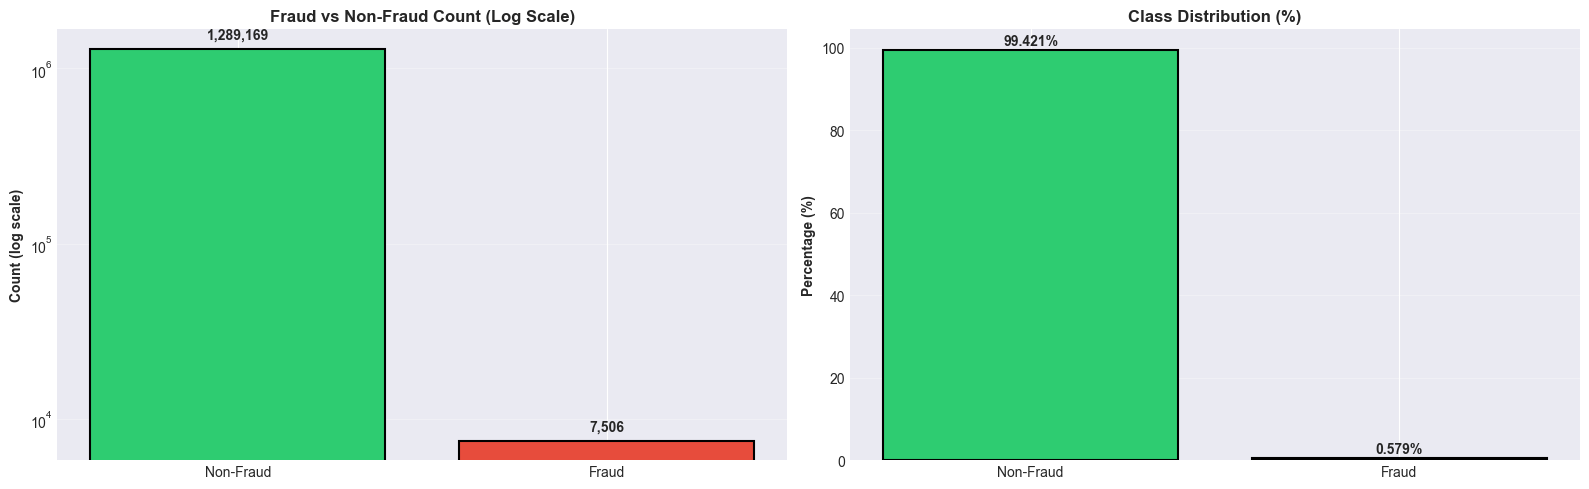


⚠️  SEVERE CLASS IMBALANCE DETECTED!
➤ Imbalance Ratio: 1:171.75
➤ For every 1 fraud transaction, there are ~172 legitimate transactions
➤ This requires special handling during model training!


In [ ]:
# Fraud distribution
print("="*50)
print("FRAUD DISTRIBUTION")
print("="*50)
fraud_counts = train['is_fraud'].value_counts()
fraud_pct = train['is_fraud'].value_counts(normalize=True) * 100

print("\nCount:")
print(fraud_counts)
print("\nPercentage:")
print(fraud_pct)

# Visualize with better approach for imbalanced data
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 2)

# Count plot with log scale
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Non-Fraud', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count (log scale)', fontweight='bold')
ax1.set_title('Fraud vs Non-Fraud Count (Log Scale)', fontweight='bold', fontsize=12)
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, v) in enumerate(zip(bars, fraud_counts.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1, f'{v:,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Percentage comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Non-Fraud', 'Fraud'], fraud_pct.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Class Distribution (%)', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
# Add value labels
for bar, v in zip(bars2, fraud_pct.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{v:.3f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

imbalance_ratio = fraud_counts[0] / fraud_counts[1]

print(f"\n{'='*50}")
print(f"⚠️  SEVERE CLASS IMBALANCE DETECTED!")
print(f"{'='*50}")
print(f"➤ Imbalance Ratio: 1:{imbalance_ratio:.2f}")
print(f"➤ For every 1 fraud transaction, there are ~{imbalance_ratio:.0f} legitimate transactions")
print(f"➤ This requires special handling during model training!")

## 3. Geographic Distribution

### 3.1 Distance (km)

Calculate distance from customer to merchant using 4 columns:
- `lat`
- `long`
- `merch_lat`
- `merch_long`

Then create a new feature: `distance_km`.

In [ ]:
geo_df = train[['is_fraud', 'lat', 'long', 'merch_lat', 'merch_long']].copy()

earth_radius_km = 6371.0
lat1 = np.radians(geo_df['lat'])
lon1 = np.radians(geo_df['long'])
lat2 = np.radians(geo_df['merch_lat'])
lon2 = np.radians(geo_df['merch_long'])

delta_lat = lat2 - lat1
delta_lon = lon2 - lon1
a = np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2
c = 2 * np.arcsin(np.sqrt(a))

train['distance_km'] = earth_radius_km * c

print("Distance calculation completed successfully!")

Distance calculation completed successfully!


Beside, there are others columns relating to location:
- `street`
- `city`
- `state`
- `zip` 
- `city_pop`   

### 3.2 Location correlation analysis

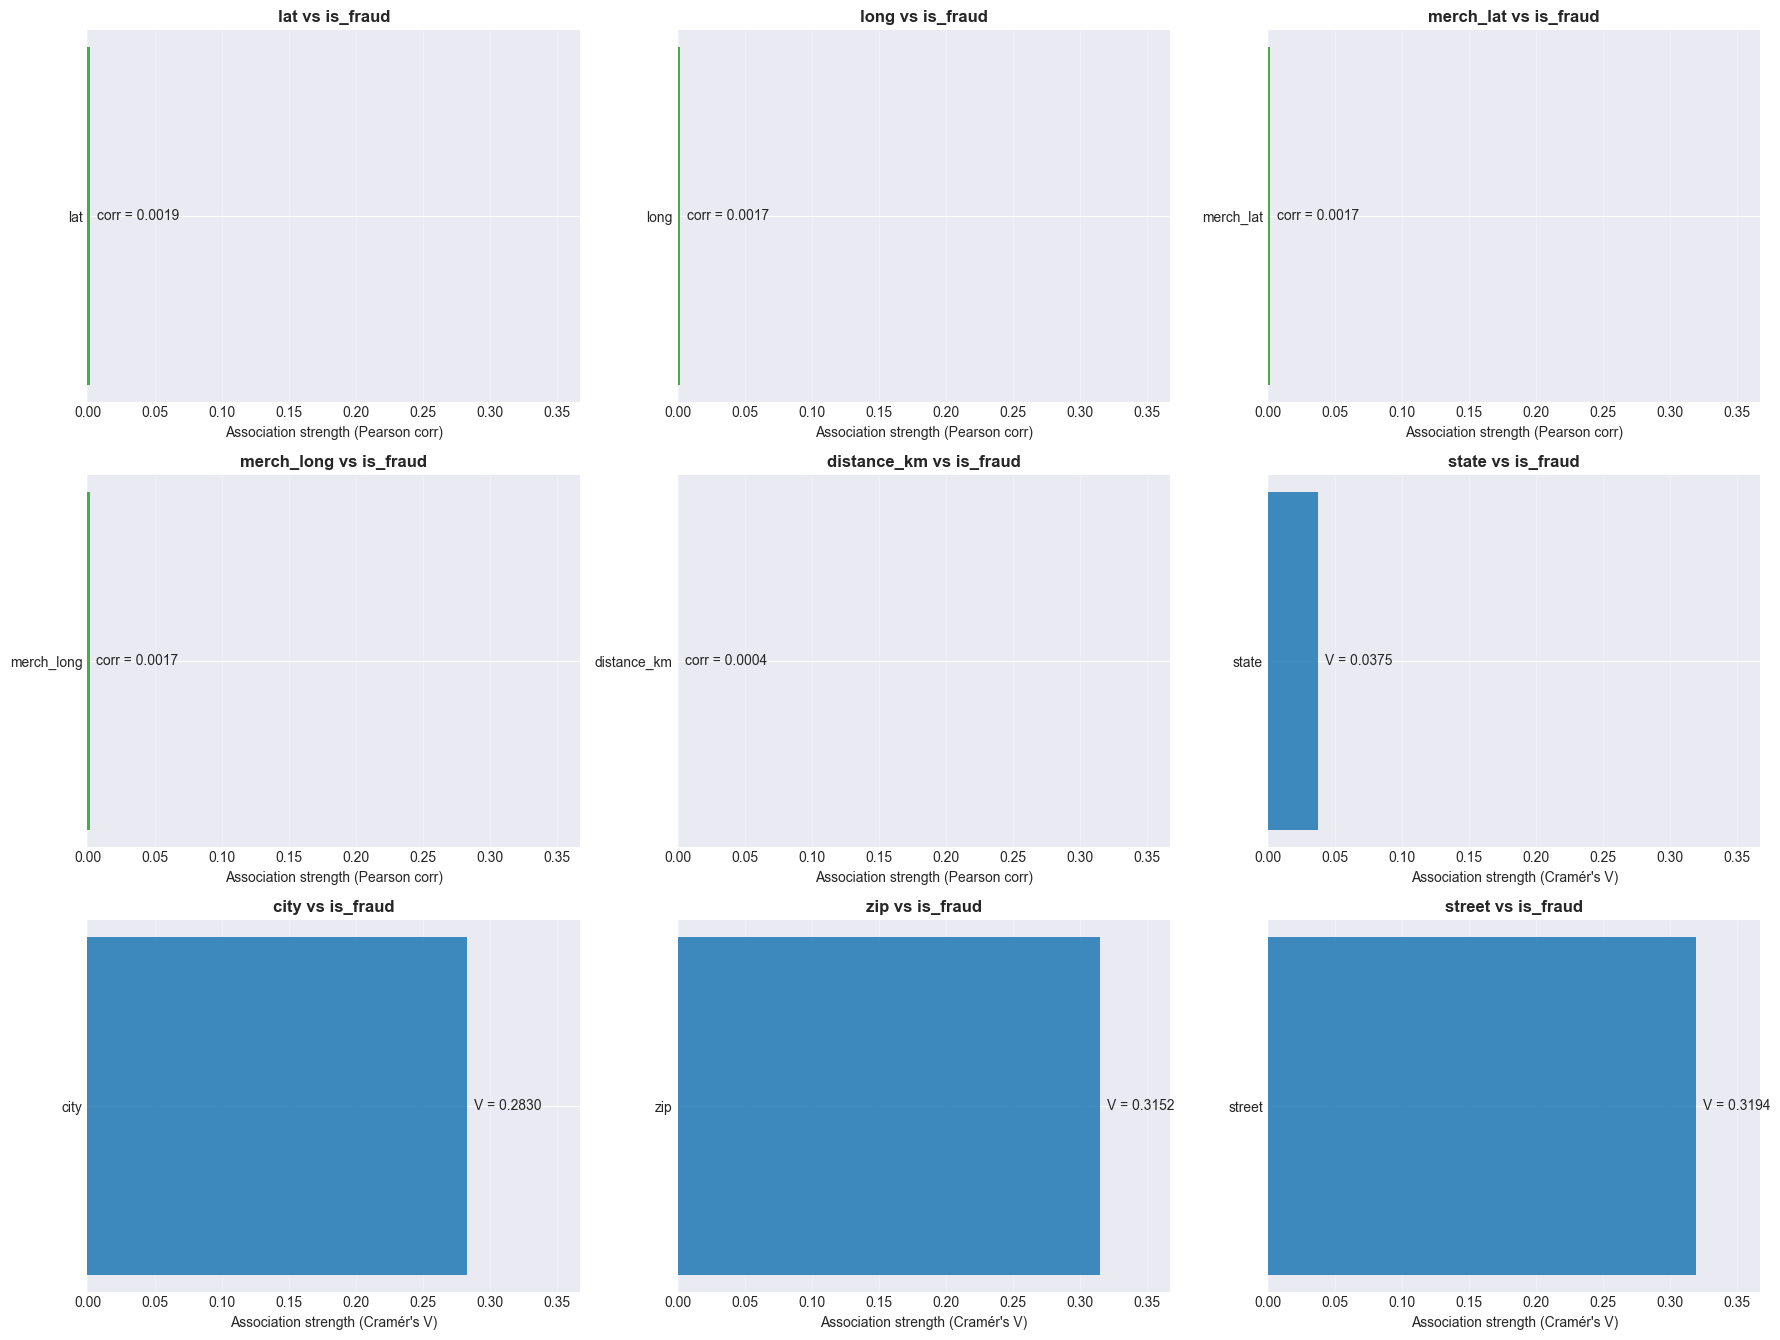

Separate feature-wise correlation charts with is_fraud completed!

Association summary:


,feature,metric,value,plot_value
0,street,Cramér's V,0.319431,0.319431
1,zip,Cramér's V,0.315177,0.315177
2,city,Cramér's V,0.283046,0.283046
3,state,Cramér's V,0.037458,0.037458
4,lat,Pearson corr,0.001894,0.001894
5,merch_lat,Pearson corr,0.001741,0.001741
6,merch_long,Pearson corr,0.001721,0.001721
7,long,Pearson corr,0.001721,0.001721
8,distance_km,Pearson corr,0.000403,0.000403


In [ ]:
from scipy.stats import chi2_contingency

# Columns related to location
loc_cat_cols = ['state', 'city', 'zip', 'street']
loc_num_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']

# Numeric correlation with target (Pearson / point-biserial because is_fraud is binary)
num_corr = train[loc_num_cols + ['is_fraud']].corr(numeric_only=True)['is_fraud'].drop('is_fraud')


def cramers_v(x, y):
    """Compute bias-corrected Cramer's V for two categorical variables."""
    ct = pd.crosstab(x, y)
    if ct.empty or min(ct.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.to_numpy().sum()
    if n <= 1:
        return np.nan

    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)

    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


# Categorical association with target
cat_assoc = {col: cramers_v(train[col].astype(str), train['is_fraud']) for col in loc_cat_cols}

# Build one record per feature for plotting separately
feature_rows = []
for col in loc_num_cols:
    feature_rows.append({
        'feature': col,
        'metric': 'Pearson corr',
        'value': num_corr[col],
        'plot_value': abs(num_corr[col])
    })

for col in loc_cat_cols:
    val = cat_assoc[col]
    feature_rows.append({
        'feature': col,
        'metric': "Cramér's V",
        'value': val,
        'plot_value': val
    })

feature_assoc_df = pd.DataFrame(feature_rows)

# Plot each feature separately against is_fraud
n_features = len(feature_assoc_df)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, row in feature_assoc_df.iterrows():
    ax = axes[i]
    feat = row['feature']
    metric = row['metric']
    value = row['value']
    plot_value = row['plot_value']

    # Color by sign for Pearson, fixed color for Cramer's V
    if metric == 'Pearson corr':
        color = '#2ca02c' if value >= 0 else '#d62728'
        label = f"corr = {value:.4f}"
    else:
        color = '#1f77b4'
        label = f"V = {value:.4f}"

    ax.barh([feat], [plot_value], color=color, alpha=0.85)
    ax.set_xlim(0, max(0.35, feature_assoc_df['plot_value'].max() * 1.15))
    ax.set_title(f"{feat} vs is_fraud", fontweight='bold')
    ax.set_xlabel(f"Association strength ({metric})")
    ax.grid(axis='x', alpha=0.25)

    ax.text(plot_value + 0.005, 0, label, va='center', fontsize=10)

# Hide unused subplots if any
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print('Separate feature-wise correlation charts with is_fraud completed!')
print('\nAssociation summary:')
display(feature_assoc_df.sort_values('plot_value', ascending=False).reset_index(drop=True))

**Location Analysis Conclusion:**
- Coordinate features (`lat`, `long`, `merch_lat`, `merch_long`) and `distance_km` show very weak association with `is_fraud`.
- Categorical location features are more informative, especially `street`, `zip`, and `city`.
- `state` contributes less than the other location categories.

## 4. Time Analysis

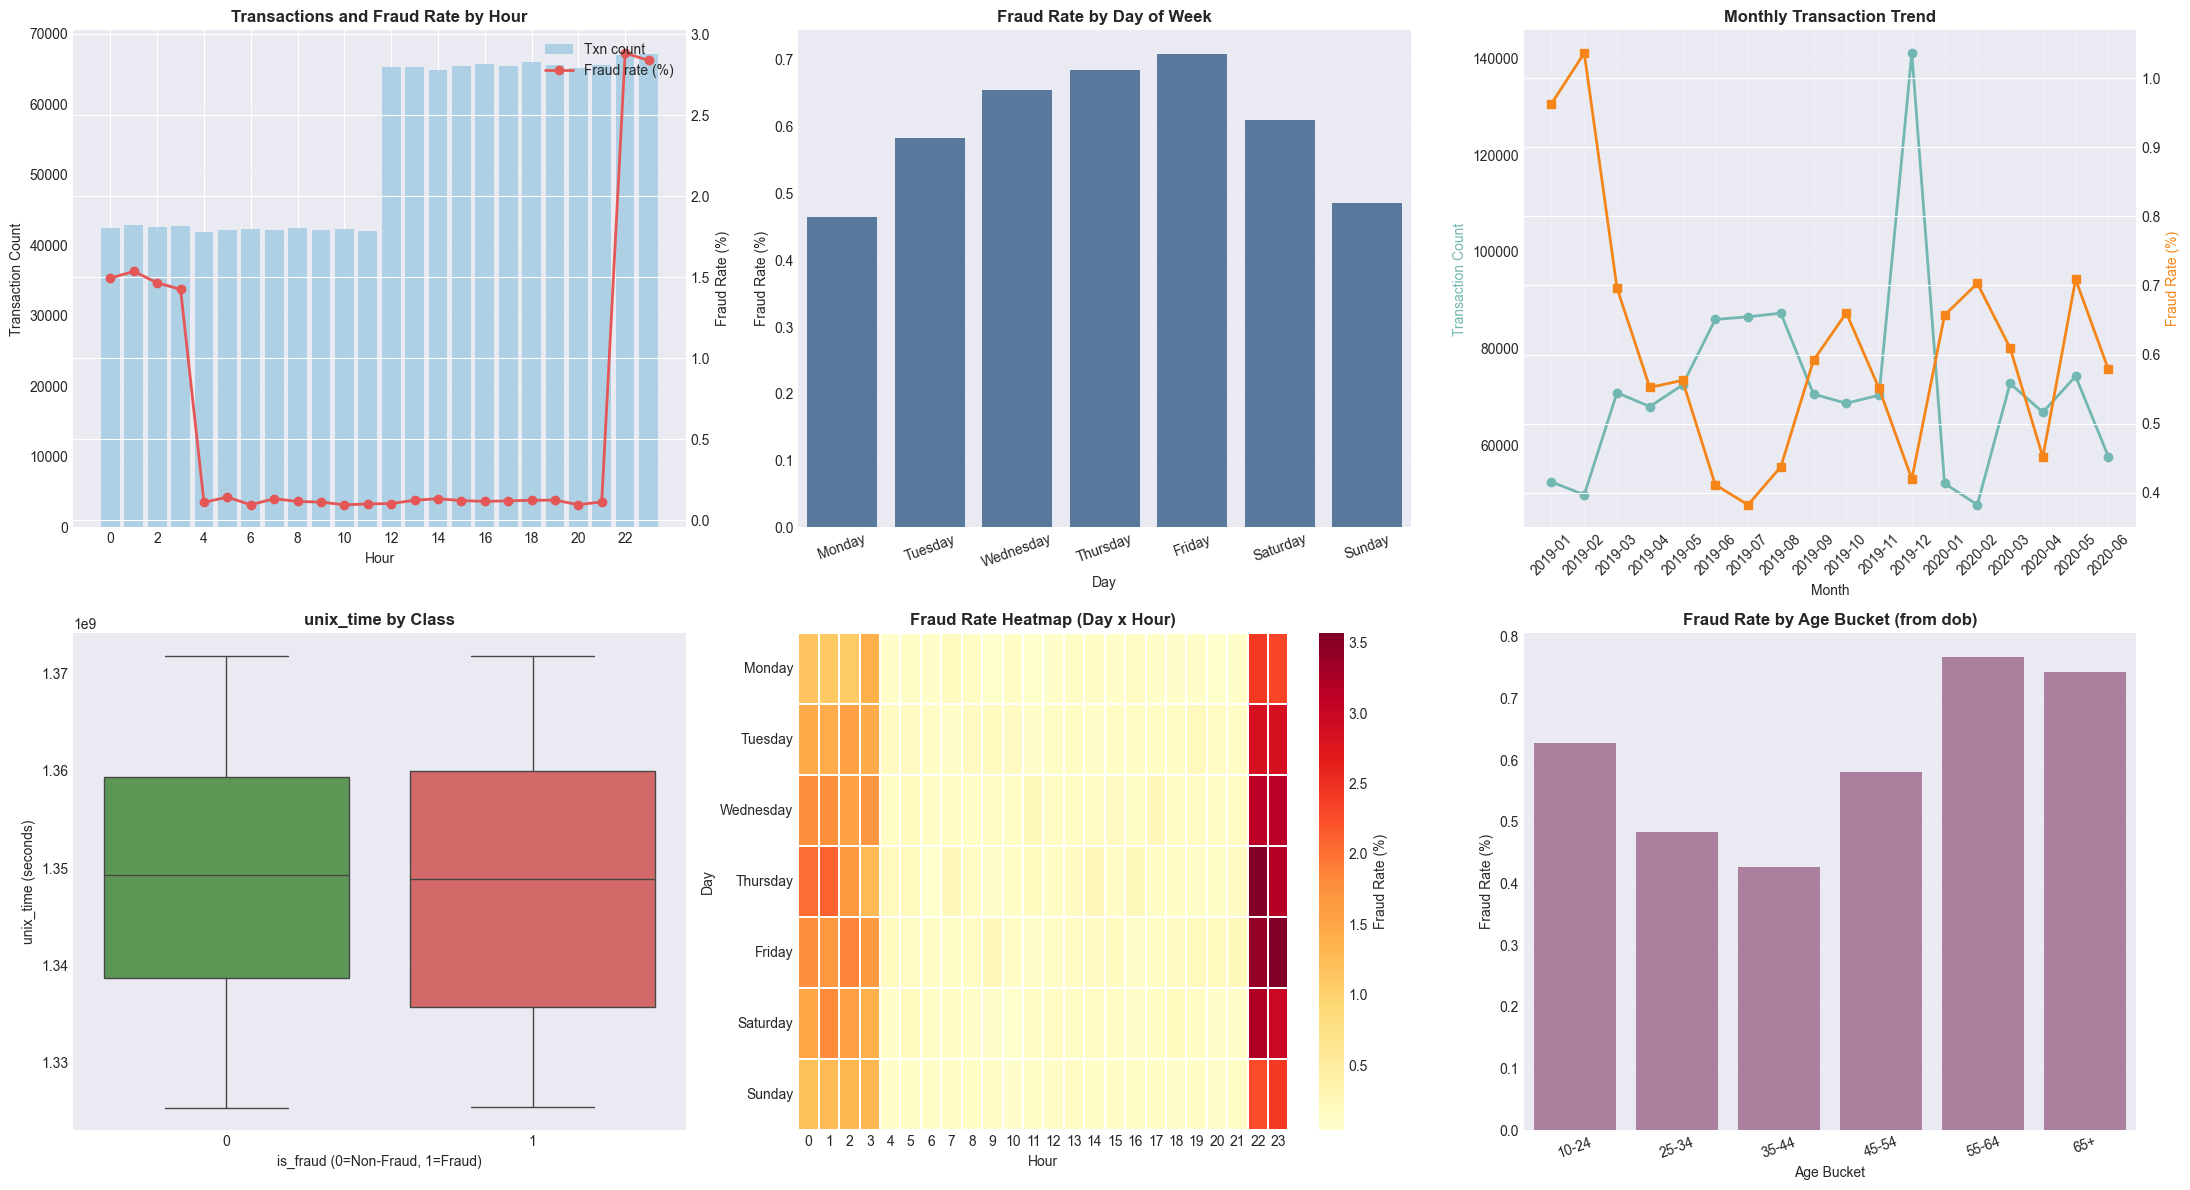

Comprehensive Time Analysis completed!
Top 3 risky hours (%):
hour
22    2.883
23    2.837
1     1.535
Name: is_fraud, dtype: float64

Top 3 risky days (%):
day_name
Friday       0.709
Thursday     0.684
Wednesday    0.655
Name: is_fraud, dtype: float64


,metric,value
0,time_column_used,trans_date_trans_time
1,corr_unix_time_is_fraud,-0.005078
2,median_signed_delta_sec (unix - parsed_datetime),-220838400.0
3,median_abs_delta_sec,220838400.0
4,median_abs_residual_sec (after removing median...,0.0
5,top_1_hour_by_fraud_rate,22:00 (2.883%)
6,top_1_day_by_fraud_rate,Friday (0.709%)


In [ ]:
# Comprehensive Time Analysis: trans datetime, unix_time, and optional DOB-derived age

# 1) Resolve and validate required columns
time_col_candidates = ['trans_date_time', 'trans_date_trans_time']
time_col = next((c for c in time_col_candidates if c in train.columns), None)

if time_col is None:
    raise ValueError(f"Cannot find datetime column. Expected one of: {time_col_candidates}")
if 'unix_time' not in train.columns:
    raise ValueError("Cannot find 'unix_time' column in dataset.")

# 2) Build base dataframe and parse datetime
time_df = train[[time_col, 'unix_time', 'is_fraud']].copy()
time_df['trans_datetime'] = pd.to_datetime(time_df[time_col], errors='coerce')
time_df['unix_time_num'] = pd.to_numeric(time_df['unix_time'], errors='coerce')

# Convert unix_time to seconds if it looks like milliseconds
time_df['unix_time_sec'] = np.where(time_df['unix_time_num'] > 1e12, time_df['unix_time_num'] / 1000, time_df['unix_time_num'])

# 3) Create time features
time_df['hour'] = time_df['trans_datetime'].dt.hour
time_df['day_name'] = pd.Categorical(
    time_df['trans_datetime'].dt.day_name(),
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)
time_df['month'] = time_df['trans_datetime'].dt.to_period('M').astype(str)
time_df['is_weekend'] = time_df['day_name'].isin(['Saturday', 'Sunday']).astype(int)

# 4) DOB -> age features (if available)
has_dob = 'dob' in train.columns
if has_dob:
    time_df['dob_dt'] = pd.to_datetime(train['dob'], errors='coerce')
    age_years = (time_df['trans_datetime'] - time_df['dob_dt']).dt.days / 365.25
    time_df['age_years'] = age_years.where((age_years >= 10) & (age_years <= 100))
    age_bins = [10, 25, 35, 45, 55, 65, 100]
    age_labels = ['10-24', '25-34', '35-44', '45-54', '55-64', '65+']
    time_df['age_bucket'] = pd.cut(time_df['age_years'], bins=age_bins, labels=age_labels, right=False)

# 5) Core aggregations
hourly_count = time_df.groupby('hour', observed=True).size().reindex(range(24), fill_value=0)
fraud_rate_by_hour = (time_df.groupby('hour', observed=True)['is_fraud'].mean() * 100).reindex(range(24))

fraud_rate_by_day = (time_df.groupby('day_name', observed=True)['is_fraud'].mean() * 100)
tx_count_by_day = time_df.groupby('day_name', observed=True).size()

month_agg = (
    time_df.groupby('month', observed=True)
    .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
    .reset_index()
    .sort_values('month')
)

# Day x hour fraud-rate heatmap
heatmap_df = (
    time_df.groupby(['day_name', 'hour'], observed=True)['is_fraud']
    .mean()
    .mul(100)
    .unstack(fill_value=np.nan)
    .reindex(index=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

# 6) unix_time consistency diagnostics
valid_mask = time_df['trans_datetime'].notna() & time_df['unix_time_sec'].notna()
epoch_sec = pd.Series(np.nan, index=time_df.index)
epoch_sec.loc[valid_mask] = (time_df.loc[valid_mask, 'trans_datetime'].astype('int64') // 10**9)

delta_sec = time_df['unix_time_sec'] - epoch_sec
median_signed_delta_sec = delta_sec.loc[valid_mask].median()
median_abs_delta_sec = delta_sec.loc[valid_mask].abs().median()
median_abs_residual_sec = (delta_sec.loc[valid_mask] - median_signed_delta_sec).abs().median()

unix_corr = time_df[['unix_time_sec', 'is_fraud']].corr(numeric_only=True).loc['unix_time_sec', 'is_fraud']

# 7) Visualizations
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# (a) Hour: count + fraud rate
ax = axes[0, 0]
ax.bar(hourly_count.index, hourly_count.values, color='#9ecae1', alpha=0.8, label='Txn count')
ax.set_title('Transactions and Fraud Rate by Hour', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Transaction Count')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', alpha=0.25)

ax_r = ax.twinx()
ax_r.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='#e45756', marker='o', linewidth=2, label='Fraud rate (%)')
ax_r.set_ylabel('Fraud Rate (%)')

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax_r.legend(lines + lines2, labels + labels2, loc='upper right')

# (b) Day of week fraud rate
sns.barplot(x=fraud_rate_by_day.index, y=fraud_rate_by_day.values, ax=axes[0, 1], color='#4c78a8')
axes[0, 1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.25)

# (c) Monthly trend (count + fraud rate)
axes[0, 2].plot(month_agg['month'], month_agg['tx_count'], marker='o', color='#72b7b2', linewidth=2)
axes[0, 2].set_title('Monthly Transaction Trend', fontweight='bold')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Transaction Count', color='#72b7b2')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(alpha=0.25)

ax2 = axes[0, 2].twinx()
ax2.plot(month_agg['month'], month_agg['fraud_rate_pct'], marker='s', color='#f58518', linewidth=2)
ax2.set_ylabel('Fraud Rate (%)', color='#f58518')

# (d) unix_time by class (boxplot for robust comparison)
sns.boxplot(data=time_df, x='is_fraud', y='unix_time_sec', ax=axes[1, 0], palette=['#54a24b', '#e45756'])
axes[1, 0].set_title('unix_time by Class', fontweight='bold')
axes[1, 0].set_xlabel('is_fraud (0=Non-Fraud, 1=Fraud)')
axes[1, 0].set_ylabel('unix_time (seconds)')
axes[1, 0].grid(axis='y', alpha=0.25)

# (e) Day x Hour fraud-rate heatmap
sns.heatmap(heatmap_df, cmap='YlOrRd', linewidths=0.3, ax=axes[1, 1], cbar_kws={'label': 'Fraud Rate (%)'})
axes[1, 1].set_title('Fraud Rate Heatmap (Day x Hour)', fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Day')

# (f) Age bucket analysis (if dob exists)
if has_dob and time_df['age_bucket'].notna().any():
    age_rate = time_df.groupby('age_bucket', observed=True)['is_fraud'].mean().mul(100)
    sns.barplot(x=age_rate.index.astype(str), y=age_rate.values, ax=axes[1, 2], color='#b279a2')
    axes[1, 2].set_title('Fraud Rate by Age Bucket (from dob)', fontweight='bold')
    axes[1, 2].set_xlabel('Age Bucket')
    axes[1, 2].set_ylabel('Fraud Rate (%)')
    axes[1, 2].tick_params(axis='x', rotation=20)
    axes[1, 2].grid(axis='y', alpha=0.25)
else:
    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, 'dob not available\nor age buckets empty', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

# 8) Compact summary table
top_hours = fraud_rate_by_hour.sort_values(ascending=False).head(3)
top_days = fraud_rate_by_day.sort_values(ascending=False).head(3)

summary_df = pd.DataFrame({
    'metric': [
        'time_column_used',
        'corr_unix_time_is_fraud',
        'median_signed_delta_sec (unix - parsed_datetime)',
        'median_abs_delta_sec',
        'median_abs_residual_sec (after removing median shift)',
        'top_1_hour_by_fraud_rate',
        'top_1_day_by_fraud_rate'
    ],
    'value': [
        time_col,
        float(unix_corr) if pd.notna(unix_corr) else np.nan,
        float(median_signed_delta_sec) if pd.notna(median_signed_delta_sec) else np.nan,
        float(median_abs_delta_sec) if pd.notna(median_abs_delta_sec) else np.nan,
        float(median_abs_residual_sec) if pd.notna(median_abs_residual_sec) else np.nan,
        f"{int(top_hours.index[0])}:00 ({top_hours.iloc[0]:.3f}%)" if len(top_hours) else np.nan,
        f"{top_days.index[0]} ({top_days.iloc[0]:.3f}%)" if len(top_days) else np.nan,
    ]
})

print('Comprehensive Time Analysis completed!')
print('Top 3 risky hours (%):')
print(top_hours.round(3))
print('\nTop 3 risky days (%):')
print(top_days.round(3))

display(summary_df)

**Time Analysis Conclusion:**
- Time features are informative: fraud rate changes by hour, day, and month.
- `unix_time` can be weakly linear with `is_fraud`, but still useful as a temporal ordering feature.
- If `dob` exists, convert it to `age`/`age_bucket` to capture demographic-time interaction; avoid using raw `dob` directly in modeling.

## 5. Transaction Amount

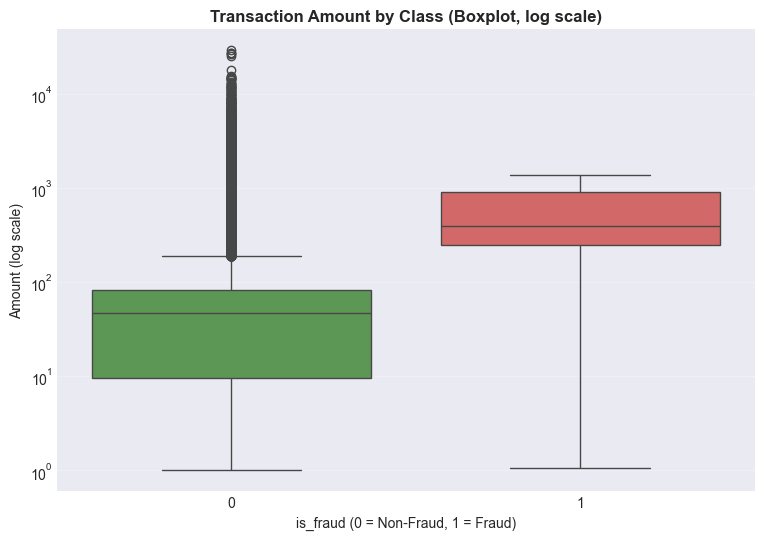

Transaction Amount boxplot completed!
Fraud class amount quartiles (reference range):
               q1  median      q3
is_fraud                         
non_fraud    9.61   47.28   82.54
fraud      245.66  396.50  900.88

Interpretation hint: the central fraud range is roughly from q1 to q3 of class 'fraud'.


In [ ]:
# Simple Transaction Amount analysis: single boxplot

if 'amt' not in train.columns:
    raise ValueError("Cannot find 'amt' column in dataset.")

amount_df = train[['amt', 'is_fraud']].copy()
amount_df['amt'] = pd.to_numeric(amount_df['amt'], errors='coerce')
amount_df = amount_df.dropna(subset=['amt', 'is_fraud'])

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=amount_df,
    x='is_fraud',
    y='amt',
    palette=['#54a24b', '#e45756']
)
plt.yscale('log')
plt.title('Transaction Amount by Class (Boxplot, log scale)', fontweight='bold')
plt.xlabel('is_fraud (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Amount (log scale)')
plt.grid(axis='y', alpha=0.25)
plt.show()

# Short numeric guidance for "which amount range has more fraud"
q = amount_df.groupby('is_fraud')['amt'].quantile([0.25, 0.5, 0.75]).unstack()
q.columns = ['q1', 'median', 'q3']
q.index = q.index.map({0: 'non_fraud', 1: 'fraud'})

print('Transaction Amount boxplot completed!')
print('Fraud class amount quartiles (reference range):')
print(q.round(2))
print("\nInterpretation hint: the central fraud range is roughly from q1 to q3 of class 'fraud'.")

## 6. Other Features
### 6.1 gender and category vs is_fraud

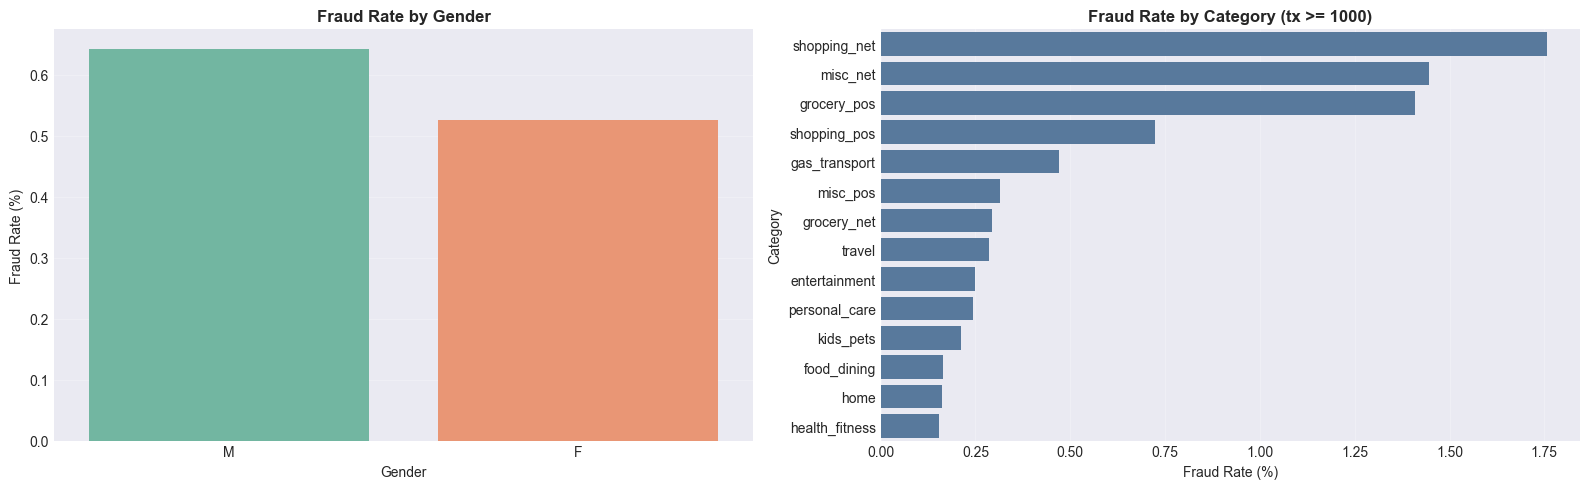

6.1 completed!


In [ ]:
# 6.1 Gender and Category vs is_fraud (simple fraud-rate bars)

feature_df = train[['gender', 'category', 'merchant', 'city_pop', 'job', 'is_fraud']].copy()

# Gender fraud rate
gender_rate = feature_df.groupby('gender')['is_fraud'].mean().mul(100).sort_values(ascending=False)

# Category fraud rate (filter categories with enough transactions for stable comparison)
cat_stats = (
    feature_df.groupby('category')
    .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
    .reset_index()
)
cat_plot = cat_stats[cat_stats['tx_count'] >= 1000].sort_values('fraud_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[0], palette='Set2')
axes[0].set_title('Fraud Rate by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].grid(axis='y', alpha=0.25)

sns.barplot(data=cat_plot, y='category', x='fraud_rate_pct', ax=axes[1], color='#4c78a8')
axes[1].set_title('Fraud Rate by Category (tx >= 1000)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Category')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

print('6.1 completed!')

### 6.2 city_pop vs is_fraud

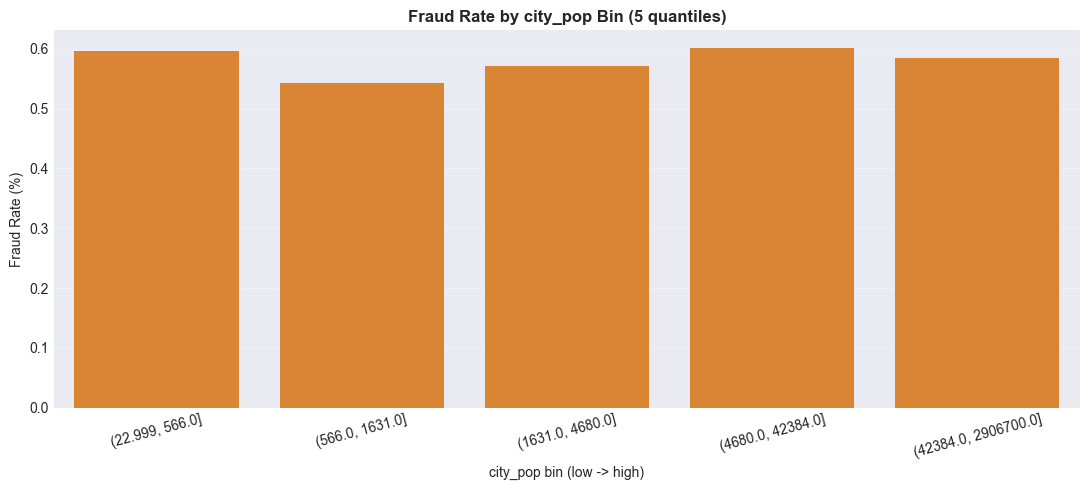

6.2 completed!


In [20]:
# Bin city_pop into quantiles, then compare fraud rate

city_df = feature_df[['city_pop', 'is_fraud']].copy()
city_df['city_pop'] = pd.to_numeric(city_df['city_pop'], errors='coerce')
city_df = city_df.dropna(subset=['city_pop'])

city_df['city_pop_bin'] = pd.qcut(city_df['city_pop'], q=5, duplicates='drop')
city_plot = (
    city_df.groupby('city_pop_bin', observed=True)['is_fraud']
    .mean()
    .mul(100)
    .reset_index(name='fraud_rate_pct')
)
city_plot['bin_label'] = city_plot['city_pop_bin'].astype(str)

plt.figure(figsize=(11, 5))
sns.barplot(data=city_plot, x='bin_label', y='fraud_rate_pct', color='#f58518')
plt.title('Fraud Rate by city_pop Bin (5 quantiles)', fontweight='bold')
plt.xlabel('city_pop bin (low -> high)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('6.2 completed!')

### 6.3 merchant and job vs is_fraud (top groups)

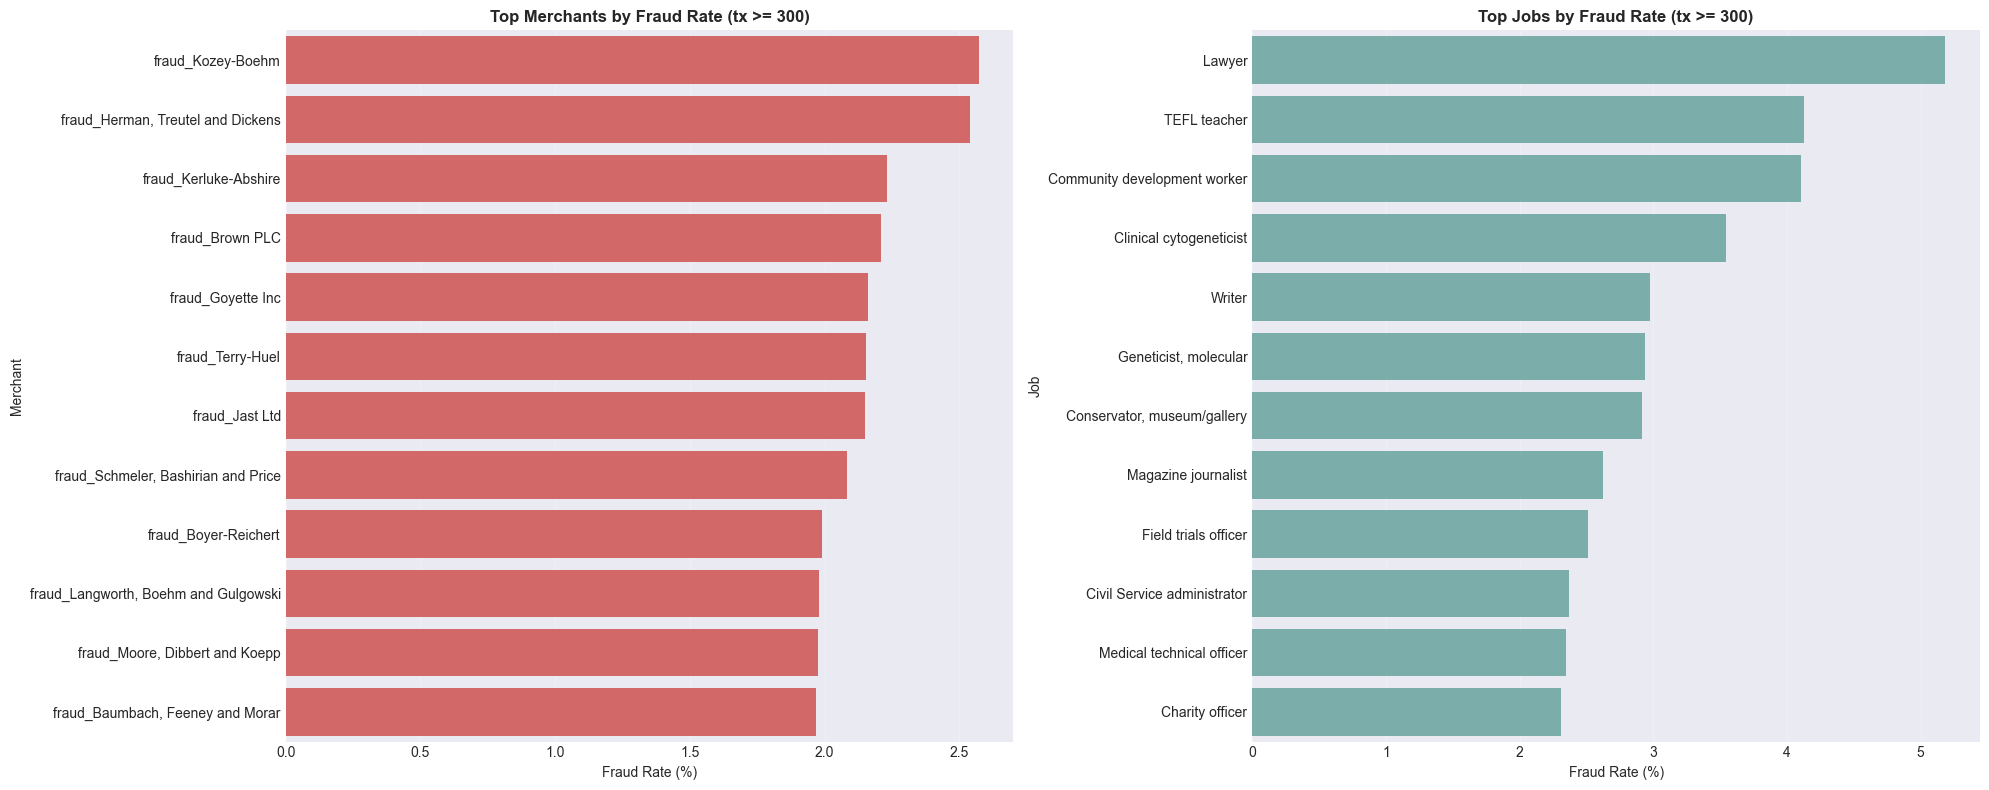

6.3 completed!


In [21]:
# Show top groups with highest fraud rate, while requiring enough samples

def top_group_fraud_rate(data, col, min_tx=300, top_n=12):
    temp = (
        data.groupby(col)
        .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
        .reset_index()
    )
    temp = temp[temp['tx_count'] >= min_tx]
    return temp.sort_values('fraud_rate_pct', ascending=False).head(top_n)

merchant_plot = top_group_fraud_rate(feature_df, 'merchant', min_tx=300, top_n=12)
job_plot = top_group_fraud_rate(feature_df, 'job', min_tx=300, top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=merchant_plot, y='merchant', x='fraud_rate_pct', ax=axes[0], color='#e45756')
axes[0].set_title('Top Merchants by Fraud Rate (tx >= 300)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Merchant')
axes[0].grid(axis='x', alpha=0.25)

sns.barplot(data=job_plot, y='job', x='fraud_rate_pct', ax=axes[1], color='#72b7b2')
axes[1].set_title('Top Jobs by Fraud Rate (tx >= 300)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Job')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

print('6.3 completed!')

## 7. General Conclusion

- The dataset is highly imbalanced, so model training should use imbalance-aware strategies.
- Time features are useful: fraud risk changes clearly by hour and day, with peaks in late-night periods.
- Transaction amount is one of the strongest indicators: fraudulent transactions are typically much higher than normal ones.
- Location and other categorical features (`merchant`, `category`, `job`, `street`, `zip`, `city`) provide additional signal and help separate risky patterns.
- `city_pop` and some numeric location features show weaker direct effect, but can still support model performance when combined with stronger features.

**Recommended next step:** prioritize feature engineering from `amt`, time-based fields, and high-cardinality categorical encodings before model training.